# Logistic Regression Classification on Ecommerce Data

This notebook demonstrates a **classification use case** using **Logistic Regression**.

## Objective
Predict whether an order is **returned (1)** or **not returned (0)** based on ecommerce order features.

## Dataset
- 1000 rows
- 10 columns
- Mix of categorical and numerical features

## Target Column
- `returned`


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay

df = pd.read_csv('ecommerce_classification_data.csv')
df.head()


,order_id,product_category,customer_segment,payment_method,region,unit_price,quantity,discount_percent,customer_rating,returned
0,10001,Beauty,Loyal,Wallet,South,504.45,4,9.42,4.3,0
1,10002,Sports,Returning,Card,West,3168.36,4,6.95,3.2,0
2,10003,Home,Returning,Card,East,4908.71,4,27.42,3.3,0
3,10004,Sports,Loyal,Wallet,West,1072.02,2,31.82,2.8,0
4,10005,Sports,Returning,COD,West,3994.09,5,12.96,4.1,0


## 1. Basic exploration

In [2]:
print(df.shape)
print(df.columns)

print(df["returned"].value_counts())
print(df["returned"].value_counts(normalize=True))

df.head()

(1000, 10)
Index(['order_id', 'product_category', 'customer_segment', 'payment_method',
       'region', 'unit_price', 'quantity', 'discount_percent',
       'customer_rating', 'returned'],
      dtype='str')
returned
0    796
1    204
Name: count, dtype: int64
returned
0    0.796
1    0.204
Name: proportion, dtype: float64


,order_id,product_category,customer_segment,payment_method,region,unit_price,quantity,discount_percent,customer_rating,returned
0,10001,Beauty,Loyal,Wallet,South,504.45,4,9.42,4.3,0
1,10002,Sports,Returning,Card,West,3168.36,4,6.95,3.2,0
2,10003,Home,Returning,Card,East,4908.71,4,27.42,3.3,0
3,10004,Sports,Loyal,Wallet,West,1072.02,2,31.82,2.8,0
4,10005,Sports,Returning,COD,West,3994.09,5,12.96,4.1,0


In [8]:
df.info()

print(df.isna().sum())

print(df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          1000 non-null   int64  
 1   product_category  1000 non-null   str    
 2   customer_segment  1000 non-null   str    
 3   payment_method    1000 non-null   str    
 4   region            1000 non-null   str    
 5   unit_price        1000 non-null   float64
 6   quantity          1000 non-null   int64  
 7   discount_percent  1000 non-null   float64
 8   customer_rating   1000 non-null   float64
 9   returned          1000 non-null   int64  
dtypes: float64(3), int64(3), str(4)
memory usage: 99.0 KB
order_id            0
product_category    0
customer_segment    0
payment_method      0
region              0
unit_price          0
quantity            0
discount_percent    0
customer_rating     0
returned            0
dtype: int64
0


## 2. Prepare features and target

In [9]:
X = df.drop(columns=["returned"])
y = df["returned"]

print(X.shape)
print(y.shape)

(1000, 9)
(1000,)


## 3. Train-test split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## 4. Build preprocessing + Logistic Regression pipeline

In [12]:
from sklearn.impute import SimpleImputer
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical cols:", categorical_cols)
print("Numerical cols  :", numerical_cols)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numerical_cols)
    ],
    remainder="drop"
)

clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

clf.fit(X_train, y_train)
print("Model training done")

Categorical cols: ['product_category', 'customer_segment', 'payment_method', 'region']
Numerical cols  : ['order_id', 'unit_price', 'quantity', 'discount_percent', 'customer_rating']
Model training done


C:\Users\Neena.Johnson\AppData\Local\Temp\ipykernel_12012\3161971329.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()


## 5. Predictions and evaluation

In [ ]:
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1] 

print("Predictions done")

Predictions done


In [14]:
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.81
              precision    recall  f1-score   support

           0       0.81      0.97      0.89       151
           1       0.79      0.31      0.44        49

    accuracy                           0.81       200
   macro avg       0.80      0.64      0.66       200
weighted avg       0.81      0.81      0.78       200



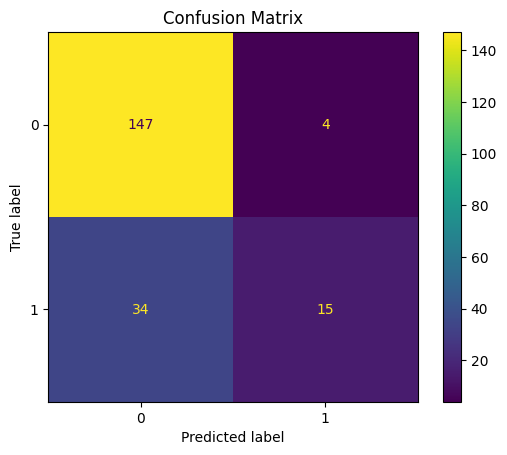

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix")
plt.show()

## 6. Predict on sample new records

In [18]:
sample = X.iloc[[0]].copy()
sample_pred = clf.predict(sample)[0]
sample_prob = clf.predict_proba(sample)[0, 1]

print("Sample prediction:", sample_pred)
print("Probability returned:", sample_prob)

sample2 = sample.copy()

for col, val in [
    ("payment_method", "Card"),
    ("region", "South"),
]:
    if col in sample2.columns:
        sample2[col] = val

sample2_pred = clf.predict(sample2)[0]
sample2_prob = clf.predict_proba(sample2)[0, 1]

print("Edited sample prediction:", sample2_pred)
print("Probability returned:", sample2_prob)

Sample prediction: 0
Probability returned: 0.013316864529284395
Edited sample prediction: 0
Probability returned: 0.00917486775800411


## 7. Feature importance insight

For logistic regression, coefficients help us understand the direction of impact.


Top 10 features increasing return probability:
                         feature      coef
6           customer_segment_New  0.813802
8             payment_method_COD  0.748280
19              discount_percent  0.607744
1   product_category_Electronics  0.528076
13                  region_North  0.453540
18                      quantity  0.360945
7     customer_segment_Returning  0.149807
17                    unit_price  0.118232
0        product_category_Beauty  0.076123
16                      order_id  0.053524

Top 10 features decreasing return probability:
                     feature      coef
3      product_category_Home -0.054110
12               region_East -0.071772
10        payment_method_UPI -0.072639
11     payment_method_Wallet -0.151459
4    product_category_Sports -0.193823
2   product_category_Fashion -0.360295
14              region_South -0.388847
20           customer_rating -0.524893
9        payment_method_Card -0.528212
5     customer_segment_Loyal -0.967639


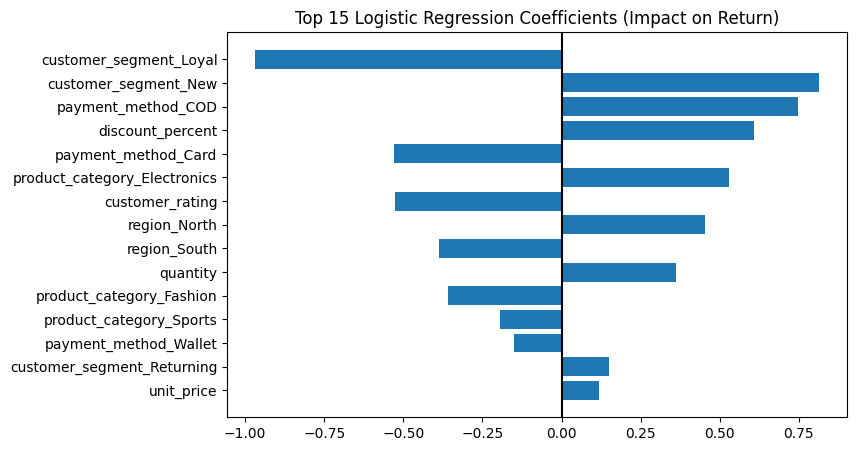

In [20]:
ohe = clf.named_steps["preprocess"].named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(categorical_cols)

all_feature_names = np.concatenate([cat_feature_names, np.array(numerical_cols)])

coefs = clf.named_steps["model"].coef_[0]

feature_importance = pd.DataFrame({
    "feature": all_feature_names,
    "coef": coefs
}).sort_values("coef", ascending=False)

print("Top 10 features increasing return probability:")
print(feature_importance.head(10))

print("\nTop 10 features decreasing return probability:")
print(feature_importance.tail(10))

top_abs = feature_importance.reindex(feature_importance["coef"].abs().sort_values(ascending=False).head(15).index)

plt.figure(figsize=(8, 5))
plt.barh(top_abs["feature"], top_abs["coef"])
plt.axvline(0, color="black")
plt.title("Top 15 Logistic Regression Coefficients (Impact on Return)")
plt.gca().invert_yaxis()
plt.show()